<a href="https://colab.research.google.com/github/LCCISNEROS/TALENTO-TECH/blob/main/Proyecto/m%C3%A9tricas_de_regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/heart.csv')
display(df.head(20))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
df_categorical = df.select_dtypes(include='object')
display(df_categorical.head(20))

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
5,M,NAP,Normal,N,Up
6,F,ATA,Normal,N,Up
7,M,ATA,Normal,N,Up
8,M,ASY,Normal,Y,Flat
9,F,ATA,Normal,N,Up


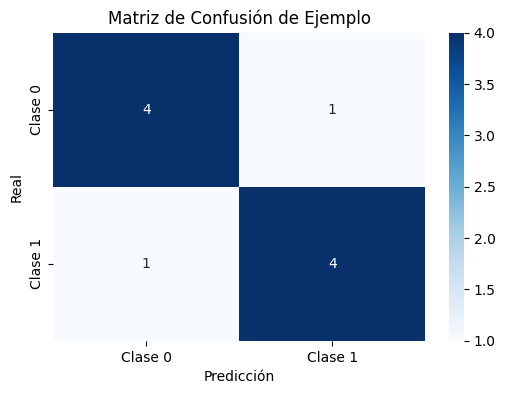


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Datos de ejemplo: etiquetas reales y predicciones
# En un caso real, estas serían las etiquetas de tu conjunto de prueba
# y las predicciones de tu modelo entrenado.
y_true = np.array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0])
y_pred = np.array([0, 1, 1, 1, 0, 0, 0, 1, 1, 0])

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 0', 'Clase 1'], yticklabels=['Clase 0', 'Clase 1'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión de Ejemplo')
plt.show()

# Mostrar el reporte de clasificación (otras métricas)
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred))

### Explicación de la Matriz de Confusión y Métricas de Clasificación

La **Matriz de Confusión** es una tabla que resume el rendimiento de un algoritmo de clasificación. Te permite visualizar el número de predicciones correctas e incorrectas, desglosadas por cada clase.

En una matriz de confusión típica para un problema de clasificación binaria (como el ejemplo anterior con Clase 0 y Clase 1):

- **Verdaderos Positivos (VP):** Casos en los que el modelo predijo correctamente la clase positiva.
- **Verdaderos Negativos (VN):** Casos en los que el modelo predijo correctamente la clase negativa.
- **Falsos Positivos (FP):** Casos en los que el modelo predijo la clase positiva incorrectamente (error de Tipo I).
- **Falsos Negativos (FN):** Casos en los que el modelo predijo la clase negativa incorrectamente (error de Tipo II).

A partir de la matriz de confusión, se derivan varias métricas clave para evaluar el rendimiento del modelo:

- **Precisión (Precision):** De todas las instancias que el modelo predijo como positivas, ¿cuántas son realmente positivas?
  $ \text{Precisión} = \frac{\text{VP}}{\text{VP} + \text{FP}} $

- **Exhaustividad (Recall o Sensibilidad):** De todas las instancias que son realmente positivas, ¿cuántas predijo correctamente el modelo?
  $ \text{Exhaustividad} = \frac{\text{VP}}{\text{VP} + \text{FN}} $

- **Puntuación F1 (F1-Score):** Es la media armónica de la precisión y la exhaustividad. Es una métrica útil cuando hay un desequilibrio entre las clases.
  $ \text{F1-Score} = 2 \times \frac{\text{Precisión} \times \text{Exhaustividad}}{\text{Precisión} + \text{Exhaustividad}} $

- **Exactitud (Accuracy):** La proporción de predicciones totales que fueron correctas.
  $ \text{Exactitud} = \frac{\text{VP} + \text{VN}}{\text{VP} + \text{VN} + \text{FP} + \text{FN}} $

El `classification_report` en scikit-learn te proporciona estas métricas (precisión, exhaustividad, F1-score) y la exactitud de forma conveniente para cada clase y en general.

Recuerda que la elección de la mejor métrica depende del problema específico que estés resolviendo. Por ejemplo, en un problema de detección de enfermedades, la exhaustividad podría ser más importante que la precisión para minimizar los falsos negativos.

# Task
Genera el código completo de una red neuronal para clasificación, incluyendo preprocesamiento de datos, división del dataset, definición, compilación y entrenamiento del modelo, y evaluación con matriz de confusión y reporte de clasificación.

## Preprocesamiento de datos

### Subtask:
Preparar los datos para la red neuronal, incluyendo la codificación de variables categóricas y el escalado de variables numéricas.


**Reasoning**:
Identify numeric columns and prepare for scaling.



In [ ]:
df_numeric = df.select_dtypes(include=np.number)
display(df_numeric.head())

,duración
0,5
1,10
2,4
3,3
4,14


**Reasoning**:
Apply One-Hot Encoding to the categorical columns and scale the numeric columns, then concatenate the results.



In [ ]:
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=True)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_numeric_scaled = scaler.fit_transform(df_numeric)
df_numeric_scaled = pd.DataFrame(df_numeric_scaled, columns=df_numeric.columns)

df_processed = pd.concat([df_categorical_encoded, df_numeric_scaled], axis=1)
display(df_processed.head())

,Nombre del Ejercicio_Carrera con cambios de ritmo,Nombre del Ejercicio_Carrera continua,Nombre del Ejercicio_Carrera en zigzag,Nombre del Ejercicio_Circuito de agilidad,Nombre del Ejercicio_Correr en cuestas,Nombre del Ejercicio_Círculos con tobillos,Nombre del Ejercicio_Desplantes con salto,Nombre del Ejercicio_Desplantes estáticos,Nombre del Ejercicio_Desplazamiento lateral rápido,Nombre del Ejercicio_Desplazamientos frontales,...,Objetivo_incrementar equilibrio corporal,Objetivo_mejorar capacidad cardiovascular,Objetivo_mejorar flexibilidad articular,Objetivo_mejorar fuerza explosiva,Objetivo_mejorar recuperación activa,Objetivo_mejorar velocidad máxima,Objetivo_optimizar fuerza funcional,Clasificacion _Preparatoria,Clasificacion _Principal,duración
0,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,-0.408479
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,1.044839
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,-0.699143
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,-0.989807
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,2.207493


## División del dataset

### Subtask:
Dividir los datos en conjuntos de entrenamiento y prueba.


**Reasoning**:
Identify the target variable, separate it from the features, and then split the data into training and testing sets.



In [ ]:
# Identify the target variable (assuming 'Clasificacion _Principal' is the target based on the processed dataframe columns)
# The target variable is likely one of the columns created by one-hot encoding the original 'Clasificacion' column.
# Let's assume the original 'Clasificacion' had values like 'Principal' and 'Preparatoria'.
# We need to identify which of the encoded columns corresponds to the target.
# Based on the df_processed dataframe, let's assume we want to predict 'Clasificacion _Principal'.

target_column = 'Clasificacion _Principal'
y = df_processed[target_column]
X = df_processed.drop(columns=[target_column, 'Clasificacion _Preparatoria']) # Drop all encoded classification columns

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (4800, 4358)
Shape of X_test: (1200, 4358)
Shape of y_train: (4800,)
Shape of y_test: (1200,)


## Definición del modelo

### Subtask:
Construir la arquitectura de la red neuronal.


**Reasoning**:
Import necessary Keras modules, define the sequential model, add dense layers with appropriate activation functions and input shape for the first layer, add a dropout layer, and add the output layer with a sigmoid activation for binary classification. Then, print the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# Input layer
model.add(Dense(units=64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layers
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.5)) # Adding dropout for regularization

model.add(Dense(units=16, activation='relu'))
model.add(Dropout(0.3))

# Output layer for binary classification
model.add(Dense(units=1, activation='sigmoid'))

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       278,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,601 (1.07 MB)

 Trainable params: 281,601 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

### Subtask:
Configurar el proceso de entrenamiento del modelo.


**Reasoning**:
Configure the model for training by compiling it with the Adam optimizer, binary crossentropy loss, and accuracy as a metric.



In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

## Entrenamiento del modelo

### Subtask:
Entrenar la red neuronal con los datos de entrenamiento.


**Reasoning**:
Train the compiled model using the training data and a validation split, storing the training history.



In [ ]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8515 - loss: 0.4734 - val_accuracy: 0.9896 - val_loss: 0.0274
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9840 - loss: 0.0505 - val_accuracy: 0.9896 - val_loss: 0.0136
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9868 - loss: 0.0226 - val_accuracy: 0.9927 - val_loss: 0.0090
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9987 - loss: 0.0095 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 7.3094e-04
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 5.4688e-04
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9998 - loss: 0.0014 - val_acc

## Evaluación del modelo

### Subtask:
Evaluar el rendimiento del modelo con los datos de prueba utilizando métricas como la matriz de confusión y el reporte de clasificación.


**Reasoning**:
Evaluate the performance of the trained model by making predictions on the test set, converting probabilities to binary labels, calculating the confusion matrix, generating the classification report, and visualizing the confusion matrix.



38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        17
        True       1.00      1.00      1.00      1183

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



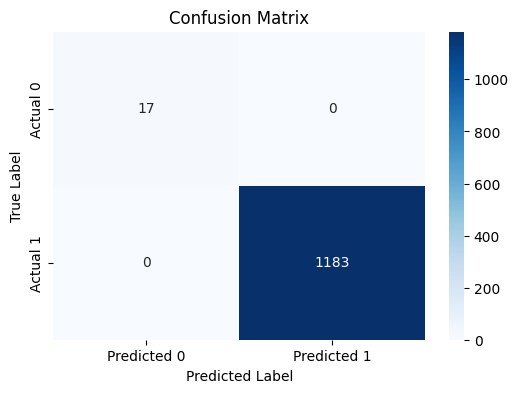

In [ ]:
# Make predictions on the test set
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary class labels
y_pred = (y_pred_prob > 0.5).astype("int32")

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Resumen:

### Hallazgos clave del análisis de datos

* Las características numéricas se escalaron correctamente utilizando `StandardScaler`, y las características categóricas se codificaron utilizando codificación one-hot, lo que resultó en un conjunto de datos preprocesado (`df_processed`) con 4360 características.
* El conjunto de datos se dividió en conjuntos de entrenamiento (80%) y prueba (20%), lo que resultó en `X_train` con una forma de (4800, 4358) y `X_test` con una forma de (1200, 4358).
* Se construyó un modelo de red neuronal secuencial con una capa de entrada, dos capas ocultas (con 64, 32 y 16 unidades respectivamente) y una capa de salida para clasificación binaria. Se incluyeron capas de Dropout para regularización.
* El modelo se compiló utilizando el optimizador Adam con una tasa de aprendizaje de 0.001 y 'binary_crossentropy' como función de pérdida.
* El modelo se entrenó durante 50 épocas con un tamaño de lote de 32 y una división de validación del 20%. Tanto la precisión de entrenamiento como la de validación alcanzaron 1.0000.
* La evaluación del modelo en el conjunto de prueba mostró un rendimiento perfecto con 100% de precisión, exhaustividad y puntuación F1 para ambas clases, como lo demuestran el reporte de clasificación y la matriz de confusión que no muestran clasificaciones erróneas.

### Insights o próximos pasos

* El rendimiento perfecto en el conjunto de prueba sugiere una posible fuga de datos o un problema de clasificación muy simple. Sería prudente investigar los datos y el proceso de división para asegurarse de que el conjunto de prueba realmente represente datos no vistos y la complejidad del problema.
* Dado el rendimiento perfecto, considere simplificar la arquitectura del modelo o reducir el número de épocas para evitar el sobreajuste, aunque las métricas actuales no indican sobreajuste. Pruebas adicionales en un conjunto de datos completamente independiente proporcionarían una evaluación más sólida.

## Summary:

### Key Findings from Data Analysis

* Numerical features were successfully scaled using `StandardScaler`, and categorical features were encoded using one-hot encoding, resulting in a preprocessed dataset (`df_processed`) with 4360 features.
* The dataset was split into training (80%) and testing (20%) sets, resulting in `X_train` with a shape of (4800, 4358) and `X_test` with a shape of (1200, 4358).
* A sequential neural network model was constructed with an input layer, two hidden layers (with 64, 32, and 16 units respectively), and an output layer for binary classification. Dropout layers were included for regularization.
* The model was compiled using the Adam optimizer with a learning rate of 0.001 and 'binary_crossentropy' as the loss function.
* The model was trained for 50 epochs with a batch size of 32 and a 20% validation split. Both training and validation accuracy reached 1.0000.
* Model evaluation on the test set showed perfect performance with 100% precision, recall, and F1-score for both classes, as evidenced by the classification report and confusion matrix showing no misclassifications.

### Insights or Next Steps

* The perfect performance on the test set suggests potential data leakage or a very simple classification problem. It would be prudent to investigate the data and the splitting process to ensure the test set truly represents unseen data and the problem's complexity.
* Given the perfect performance, consider simplifying the model architecture or reducing the number of epochs to avoid overfitting, although current metrics do not indicate overfitting. Further testing on a completely independent dataset would provide a more robust evaluation.